El siguiente documento presenta los entrenamientos de un modelo de arbol de clasificacion dado que suele tener un buen desempeño con datos tabulares, que es precisamente la forma en la que se ha dispuesto lo datos agregados. Este sirve como punto comparación para arquitecturas más complejas o que empleen datos crudos.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
    - Descripcion
- Long Short-Term Memory (LSTM)
    - Descripcion
- Recurrent Neural Network (RNN)
    - Descripcion
- Deep Neural Network (DNN)
    - Descripcion


El conjunto de datos empleado se componen de 17.248 filas y 20 columnas. En este cada fila corresponde a una medición del experimento 1st_test, es el primero de 3 experimentos que conforman el dataset [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre viabraciones elementos rodantes. Las columnas corresponde a diferentes parametros y estadísticos, algunos de ellos son: amplitud maxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.

# Declaración de librerias


In [4]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# Arbol de clasificacion

## Limpieza de datos

In [5]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [6]:
X = df.drop(columns=["salud", "salud_miltos", "archivo", "canal"])
y = df["salud_miltos"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

In [7]:
# balanceo de clases
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

## #1 Búsqueda de hiperparametros y entrenamiento

In [13]:
# BUSQUEDA DE HIPERPARÁMETROS CON GRIDSEARCHCV

param_grid = {
    "n_estimators": [300,400, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [7,8,9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    # num_class=len(le.classes_),
    num_class=len(classes),
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train, sample_weight=[class_weight_dict[y] for y in y_train])


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=1.0; total time=  23.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=  23.4s


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:58:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:58:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=  24.1s


...

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=300, subsample=1.0; total time=  18.9s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=300, subsample=1.0; total time=  18.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=300, subsample=0.8; total time=  19.5s


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:10:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:10:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:10:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=0.8; total time=  23.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=1.0; total time=  23.3s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=1.0; total time=  23.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=0.8; total time=  24.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=1.0; total time=  23.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=400, subsample=0.8; total time=  24.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=500, subsample=1.0; total time=  23.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=500, subsample=1.0; total time=  23.6s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=9, n_estimators=500,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:11:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=7, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [7, 8, 9],
                         'n_estimators': [300, 400, 500],
                         'subsample': [0.8, 1.0]},
             scoring='precision_macro', verbose=2)

In [14]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

Mejor Precision macro CV: 0.9020098030967256
Mejores hiperparámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}


### Evaluación

In [15]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.8910144927536232
                         precision    recall  f1-score   support

                  Early       0.89      0.89      0.89       539
       Inminent failure       0.63      0.59      0.61        37
     Inner race failure       1.00      1.00      1.00        14
                 Normal       0.92      0.90      0.91      1797
Rolling element failure       0.97      0.93      0.95       162
        Stage 2 failure       0.93      0.98      0.96       127
                Suspect       0.83      0.86      0.85       774

               accuracy                           0.89      3450
              macro avg       0.88      0.88      0.88      3450
           weighted avg       0.89      0.89      0.89      3450



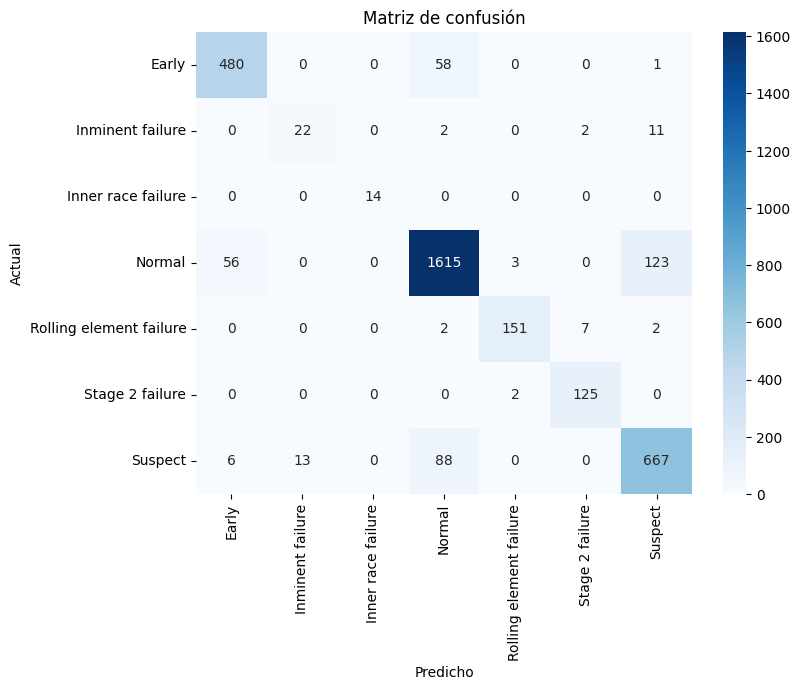

In [17]:

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.show()

## #2 Búsqueda de hiperparametros y entrenamiento

In [8]:
# BUSQUEDA DE HIPERPARÁMETROS CON GRIDSEARCHCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    # num_class=len(le.classes_),
    num_class=len(classes),
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train, sample_weight=[class_weight_dict[y] for y in y_train])


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:45:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:45:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:45:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   3.8s


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:45:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   4.0s


...

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=100, subsample=1.0; total time=   6.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=100, subsample=1.0; total time=   6.5s


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:48:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:48:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.8; total time=  11.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.8; total time=  11.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=1.0; total time=  11.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=1.0; total time=  11.0s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.8; total time=  11.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=1.0; total time=  11.6s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=300, subsample=1.0; total time=  12.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=300, subsample=0.8; total time=  13.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=7, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='f1_macro', verbose=2)

In [9]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

Mejor Precision macro CV: 0.8873528133320988
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


### Evaluación

In [10]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.8878260869565218
                         precision    recall  f1-score   support

                  Early       0.87      0.91      0.89       539
       Inminent failure       0.69      0.68      0.68        37
     Inner race failure       1.00      1.00      1.00        14
                 Normal       0.92      0.88      0.90      1797
Rolling element failure       0.96      0.93      0.95       162
        Stage 2 failure       0.93      0.98      0.96       127
                Suspect       0.81      0.87      0.84       774

               accuracy                           0.89      3450
              macro avg       0.89      0.89      0.89      3450
           weighted avg       0.89      0.89      0.89      3450



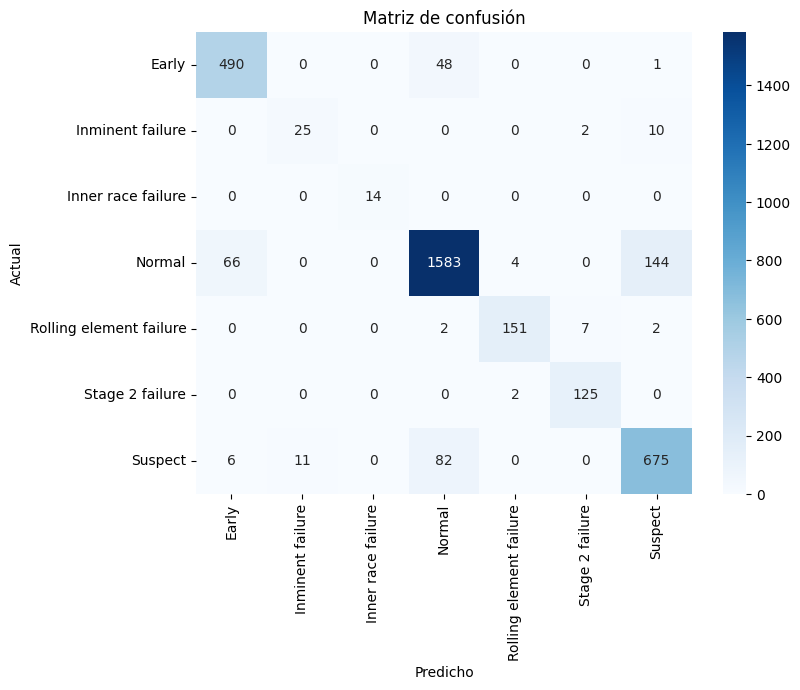

In [12]:

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.show()